<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/ex01_%EB%94%A5%EB%9F%AC%EB%8B%9D_%EB%A7%9B%EB%B3%B4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 머신러닝 vs 딥러닝
1. 머신러닝
- 데이터 속에서 규칙을 찾아서 해당 규칙을 바탕으로 새로운 데이터를 예측
- 규칙에서 조금이라도 벗어날 경우 예측 성능이 크게 저하됨

2. 딥러닝
- 사람의 경우 데이터를 구분하는 결정 경계가 유연함
- 그럼 모델들을 사람처럼 생각하게 만들어보자!

In [ ]:
# 딥러닝 개발 도구 : tensorflow, Pytorch
# 코랩에서 기본적으로 텐서플로우 제공을 함
import tensorflow as tf

tf.__version__
# 코랩에 설치된 텐서플로우 버전 확인
# 프로젝트 진행 시 오픈소스들을 가져와서 사용하는 경우가 많음
# 충돌 방지를 위해 버전 확인

'2.19.0'

In [ ]:
%cd /content/drive/MyDrive/00 딥러닝

/content/drive/MyDrive/00 딥러닝


데이터 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('./data/student-mat.csv', delimiter = ";")
# ctrl + space 자동완성
# 세미콜론으로 값이 구분되어 있음을 표시
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


| 컬럼 이름       | 설명                             |
|-----------------|----------------------------------|
| school          | 학교 (GP - Gabriel Pereira, MS - Mousinho da Silveira) |
| sex             | 성별 (F - Female, M - Male)      |
| age             | 나이                             |
| address         | 주소 유형 (U - Urban, R - Rural) |
| famsize         | 가족 크기 (LE3 - 3명 이하, GT3 - 3명 초과) |
| Pstatus         | 부모 동거 상태 (T - 함께, A - 별거) |
| Medu            | 어머니 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Fedu            | 아버지 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Mjob            | 어머니 직업 (teacher, health, services, at_home, other) |
| Fjob            | 아버지 직업 (teacher, health, services, at_home, other) |
| reason          | 학교 선택 이유 (home, reputation, course, other) |
| guardian        | 보호자 (mother, father, other)  |
| traveltime      | 통학 시간 (1 - 15분 이하, 2 - 15~30분, 3 - 30분~1시간, 4 - 1시간 초과) |
| studytime       | 주간 공부 시간 (1 - 2시간 이하, 2 - 2~5시간, 3 - 5~10시간, 4 - 10시간 초과) |
| failures        | 과목 낙제 수 (n if 1<=n<3, else 4) |
| schoolsup       | 학교 추가 지원 (yes, no)        |
| famsup          | 가족 추가 지원 (yes, no)        |
| paid            | 과외 수업 참여 (yes, no)        |
| activities      | 학교 외 활동 참여 (yes, no)     |
| nursery         | 유치원 참여 여부 (yes, no)      |
| higher          | 고등교육 희망 여부 (yes, no)    |
| internet        | 가정 내 인터넷 접속 여부 (yes, no) |
| romantic        | 로맨틱 관계 여부 (yes, no)      |
| famrel          | 가족 관계의 질 (1 - 매우 나쁨, 5 - 매우 좋음) |
| freetime        | 여가 시간의 양 (1 - 매우 적음, 5 - 매우 많음) |
| goout           | 외출 빈도 (1 - 매우 적음, 5 - 매우 많음) |
| Dalc            | 평일 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| Walc            | 주말 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| health          | 현재 건강 상태 (1 - 매우 나쁨, 5 - 매우 좋음) |
| absences        | 결석 일수                        |
| G1              | 1학기 성적                       |
| G2              | 2학기 성적                       |
| G3              | 최종 성적                        |


In [ ]:
data.info()
# 결측치가 없음

# studytime 컬럼 문제데이터로 사용해서 데이터 예측
# 최종 성적 G3 예측

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
# 1. 문제(X) - 정답(y) 데이터 분리
X = data[['studytime']]
y = data['G3']
# 주의 : 한 개의 컬럼이라도 문제 데이터는 데이터프레임화하여 저장 필수
# 한 개의 컬럼 인덱싱하면 시리즈로 결과값이 나옴 -> 데이터프레임화
# 정답 데이터는 일반적으로 시리즈를 사용

In [ ]:
# 2. train, test 데이터 분리
# 25% 데이터를 test 데이터로
# random state = 2026
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=2026
)

In [ ]:
# 3. 머신러닝 모델링
# 1) 선형회귀 모델 사용
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_model.score(X_train, y_train), linear_model.score(X_test, y_test)
# 2) 그외 다른 머신러닝 모델
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(eta0 = 0.01, verbose=1)

sgd_model.fit(X_train, y_train)

sgd_model.score(X_train, y_train), sgd_model.score(X_test, y_test)
# 1. 모델 생성

# 2. 모델 학습

# 3. 모델 평가 -> MSE

from sklearn.metrics import mean_squared_error

pred_train = linear_model.predict(X_train)
pred_test = linear_model.predict(X_test)

mse_train = mean_squared_error(y_train, pred_train)
mse_test = mean_squared_error(y_test, pred_test)

print('LinearRegression train MSE :', mse_train)
print('LinearRegression test MSE :', mse_test)

pred_train_sgd = sgd_model.predict(X_train)
pred_test_sgd = sgd_model.predict(X_test)

mse_train_sgd = mean_squared_error(y_train, pred_train_sgd)
mse_test_sgd = mean_squared_error(y_test, pred_test_sgd)

print('SGDRegressor train MSE :', mse_train_sgd)
print('SGDRegressor test MSE :', mse_test_sgd)

-- Epoch 1
Norm: 3.27, NNZs: 1, Bias: 2.469027, T: 296, Avg. loss: 17.778004
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 3.22, NNZs: 1, Bias: 3.138605, T: 592, Avg. loss: 14.715517
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 3.09, NNZs: 1, Bias: 3.638993, T: 888, Avg. loss: 14.129619
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 2.84, NNZs: 1, Bias: 4.009517, T: 1184, Avg. loss: 13.714441
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 2.74, NNZs: 1, Bias: 4.394872, T: 1480, Avg. loss: 13.356627
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 2.51, NNZs: 1, Bias: 4.674388, T: 1776, Avg. loss: 13.081592
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 2.36, NNZs: 1, Bias: 4.960450, T: 2072, Avg. loss: 12.786105
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 2.32, NNZs: 1, Bias: 5.257100, T: 2368, Avg. loss: 12.592924
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 2.25, NNZs: 1, Bias: 5.514816, T: 2664, Avg. loss: 12.420098
Total training time: 

In [ ]:
# # 1. 문제(X) - 정답(y) 데이터 분리
# X = data[["studytime"]]
# y = data["G3"]
# # 주의 : 한개의 컬럼이라도 문제데이터는 무조건 DF 으로 저장 필수

# # 2. train, test 데이터 분리
# # 25% 데이터를 test 데이터
# # 2026으로 random state 고정
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size = 0.25,
#     random_state = 2026
# )

# # 3. 머신러닝 모델링
# # 1) 선형회귀 모델 사용
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error
# # 2) 그외 다른 머신러닝 모델
# from sklearn.neighbors import KNeighborsRegressor
# # 1. 모델 생성
# model1 = LinearRegression()
# model2 = KNeighborsRegressor()

# # 2. 모델 학습
# model1.fit(X_train, y_train)
# model2.fit(X_train, y_train)

# # 3. 모델 평가 → mse
# y_pred1 = model1.predict(X_test)
# y_pred2 = model2.predict(X_test)

# print("LinearRegression :", mean_squared_error(y_test, y_pred1))
# print("KNeighborsRegressor :", mean_squared_error(y_test, y_pred2))

### 딥러닝 모델 사용

1. 신경망 구조 설계
2. 신경망 학습 방법 및 평가 방법 설정
3. 모델 학습
4. 모델 예측 및 평가

In [ ]:
# 딥러닝 설계용 도구를 tensorflow에서 불러오기
from tensorflow.keras.models import Sequential
# Sequential : 뼈대(틀), 다양한 레이어들을 순차적으로 쌓을 수 있는 기반을 마련
from tensorflow.keras.layers import Dense, InputLayer
# InputLayer : 입력을 받을 수 있는 층
# Dense : 중간층, 모든 뉴런들이 연결된 상태

In [ ]:
# 1. 신경망 구조 설계
model = Sequential() # 레이어들을 쌓을 수 있는 뼈대 생성

model.add(InputLayer(shape = (1, )))
# 문제 데이터의 형태를 shape로 넘겨줘야 함
# 현재 문제 데이터의 컬럼이 1개 -> shape = (1, )

# 중간층(은닉층, hidden layer)
# 연산 수행
model.add(Dense(64, activation = "sigmoid"))
model.add(Dense(32, activation = "sigmoid"))
# Dense에는 각 층에 들어갈 노드(뉴런)의 수를 넘겨줌
# 노드의 개수에는 정해진 정답이 없음
# 2의 제곱수들을 주로 사용(계산의 편리성 때문)
# 일반적으로 Dense 층들이 항아리 모양을 이루면 성능이 좋아짐

# 출력층
model.add(Dense(1))
# 정답 데이터의 클래스 개수
# 회귀일 경우에는 1로 설정

In [ ]:
# 2. 학습 방법 평가 및 평가 방법 설정
model.compile(
    loss = "mean_squared_error", # 모델의 오차 측정 도구(오답노트 작성 방식)
    optimizer = "SGD",           # 모델을 최적화하는 방법(경사하강법)
    metrics = ["mse"]            # 최종 평가지표
)

In [ ]:
# 3. 모델 학습
h = model.fit(
    X_train, y_train,
    validation_split = 0.2, # 검증 데이터 : 모델이 학습을 잘 하고 있는지 중간에 점검
    epochs = 20             # 전체 훈련 데이터셋을 몇 번 학습할지
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 50.3685 - mse: 50.3685 - val_loss: 27.4851 - val_mse: 27.4851
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 19.8125 - mse: 19.8125 - val_loss: 27.4776 - val_mse: 27.4776
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 19.7654 - mse: 19.7654 - val_loss: 27.5052 - val_mse: 27.5052
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 19.9820 - mse: 19.9820 - val_loss: 27.6953 - val_mse: 27.6953
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 20.2611 - mse: 20.2611 - val_loss: 27.4711 - val_mse: 27.4711
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 19.9917 - mse: 19.9917 - val_loss: 27.7141 - val_mse: 27.7141
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 20.0095 - mse: 20.0095 - val_loss: 27.4709 - val_mse: 27.4709
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 19.9061 - mse: 19.9061 - val_loss: 28.1951 - val_mse: 28.1951
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

In [ ]:
h.history
# 딕셔너리의 형태로 학습하면서 측정한 내용들이 담겨 있음

{'loss': [50.368534088134766,
  19.812450408935547,
  19.76541519165039,
  19.98200798034668,
  20.261123657226562,
  19.991748809814453,
  20.00950050354004,
  19.906105041503906,
  19.89038848876953,
  20.225492477416992,
  19.93234634399414,
  20.07337188720703,
  19.835857391357422,
  19.8843936920166,
  20.043319702148438,
  19.832759857177734,
  19.891746520996094,
  20.0538330078125,
  19.73320198059082,
  20.015640258789062],
 'mse': [50.368534088134766,
  19.812450408935547,
  19.76541519165039,
  19.98200798034668,
  20.261123657226562,
  19.991748809814453,
  20.00950050354004,
  19.906105041503906,
  19.89038848876953,
  20.225492477416992,
  19.93234634399414,
  20.07337188720703,
  19.835857391357422,
  19.8843936920166,
  20.043319702148438,
  19.832759857177734,
  19.891746520996094,
  20.0538330078125,
  19.73320198059082,
  20.015640258789062],
 'val_loss': [27.485137939453125,
  27.477628707885742,
  27.505184173583984,
  27.695329666137695,
  27.471080780029297,
  2

In [ ]:
h.history.keys()

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])

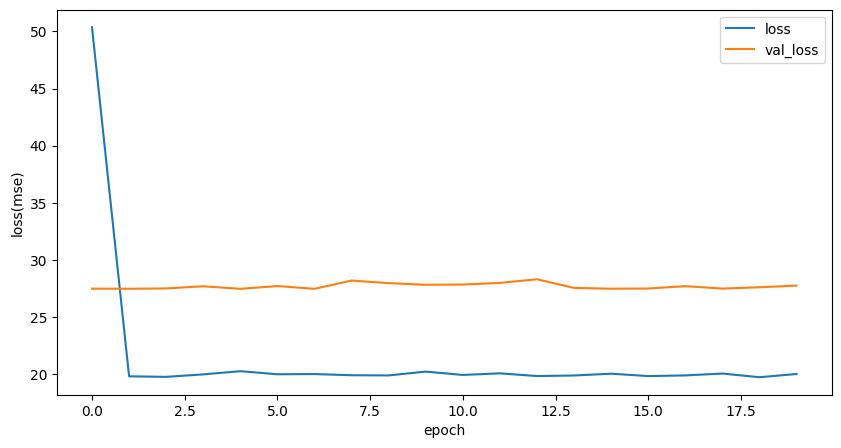

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(h.history["loss"], label = "loss")
plt.plot(h.history["val_loss"], label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss(mse)")
plt.legend()

plt.show()

# 초기 몇 에포크 동안 훈련 데이터의 오차값이 급격히 줄어듦
# 모델이 학습 초기 단계에서 모델 최적화를 위해 많은 조정을 하고 있음을 의미
# 나중에 오래 걸리는 학습을 할 때도, 첫 에포크가 가장 오래 걸리고 점점 빨라질 것

# 훈련 오차값은 어느 정도 진행하다가 안정화됨
# 검증 오차값은 학습이 진행돼도 개선이 이루어지지 않음
# 새로운 데이터를 잘 예측하지 못하는 '과대적합' 상태로 추정

# 현재 문제 데이터가 한 개의 컬럼이기 때문에 데이터가 너무 적어서 과적합된 건 아닐까?
# -> 문제 데이터를 4개의 컬럼으로 확장

In [ ]:
data.columns
# data 중에서 int형으로 된 컬럼 사용
data.select_dtypes(include=["int"]).columns

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

In [ ]:
# 1. 4개 컬럼 골라서 문제 데이터 다시 정의
X = data[['studytime', 'traveltime', 'studytime', 'health']]
y = data['G3']

In [ ]:
# 2. train, test 데이터 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=2026
)

In [ ]:
# 3. 신경망 구조 설계 -> model3
# 1) 뼈대 설계
model3 = Sequential() # 레이어들을 쌓을 수 있는 뼈대 생성
# 2) 입력층 추가
# 주의 : 문제 데이터 형태 고려해서 shape 입력
model3.add(InputLayer(shape = (4, )))
# 3) 중간층 추가 -> 첫 번째 모델과 동일한 형태
model3.add(Dense(64, activation = "sigmoid"))
model3.add(Dense(32, activation = "sigmoid"))
# 4) 출력층 추가
model3.add(Dense(1))

In [ ]:
# 4. 학습 방법 -> 첫 번째 모델과 동일한 형태
model3.compile(
    loss = "mean_squared_error", # 모델의 오차 측정 도구(오답노트 작성 방식)
    optimizer = "SGD",           # 모델을 최적화하는 방법(경사하강법)
    metrics = ["mse"]            # 최종 평가지표
)

In [ ]:
# 5. 학습 -> 첫 번째 모델과 동일한 형태
h3 = model3.fit(
    X_train, y_train,
    validation_split = 0.2, # 검증 데이터 : 모델이 학습을 잘 하고 있는지 중간에 점검
    epochs = 20             # 전체 훈련 데이터셋을 몇 번 학습할지
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 48.3553 - mse: 48.3553 - val_loss: 27.9750 - val_mse: 27.9750
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 20.1349 - mse: 20.1349 - val_loss: 27.5604 - val_mse: 27.5604
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.0122 - mse: 20.0122 - val_loss: 27.5102 - val_mse: 27.5102
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.4027 - mse: 20.4027 - val_loss: 28.7838 - val_mse: 28.7838
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.1030 - mse: 20.1030 - val_loss: 27.4339 - val_mse: 27.4339
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.0101 - mse: 20.0101 - val_loss: 27.8906 - val_mse: 27.8906
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19.8562 - mse: 19.8562 - val_loss: 27.4917 - val_mse: 27.4917
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.9983 - mse: 19.9983 - val_loss: 30.3840 - val_mse: 30.3840
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

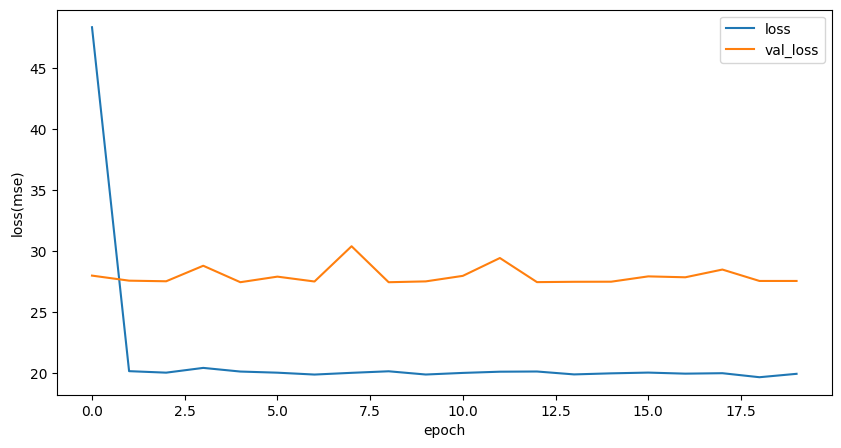

In [ ]:
# 6. 학습 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(h3.history["loss"], label = "loss")
plt.plot(h3.history["val_loss"], label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss(mse)")
plt.legend()

plt.show()
# 그래프 캡쳐해서 단톡방에 올리기

In [ ]:
print("X columns:", X.columns.tolist())
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

h3 = model3.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20
)

print("history keys:", h3.history.keys())
print("loss:", h3.history["loss"])
print("val_loss:", h3.history["val_loss"])

X columns: ['studytime', 'traveltime', 'studytime', 'health']
X_train shape: (296, 4)
y_train shape: (296,)
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 19.9814 - mse: 19.9814 - val_loss: 27.7081 - val_mse: 27.7081
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 19.7971 - mse: 19.7971 - val_loss: 28.2428 - val_mse: 28.2428
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.0388 - mse: 20.0388 - val_loss: 27.4585 - val_mse: 27.4585
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 20.1171 - mse: 20.1171 - val_loss: 27.9044 - val_mse: 27.9044
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.8919 - mse: 19.8919 - val_loss: 27.5491 - val_mse: 27.5491
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.8173 - mse: 19.8173 - val_loss: 27.5248 - val_mse: 27.5248
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.9813 - mse: 19.9813 - val_loss: 27.5565 - val_mse: 27.5565
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19

['studytime', 'traveltime', 'studytime', 'health']
(296, 4) (296,)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 58.3114 - mse: 58.3114 - val_loss: 27.4432 - val_mse: 27.4432
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 19.8920 - mse: 19.8920 - val_loss: 27.6407 - val_mse: 27.6407
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 19.9274 - mse: 19.9274 - val_loss: 27.7001 - val_mse: 27.7001
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 20.0438 - mse: 20.0438 - val_loss: 27.8145 - val_mse: 27.8145
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.8139 - mse: 19.8139 - val_loss: 27.9305 - val_mse: 27.9305
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.9666 - mse: 19.9666 - val_loss: 27.7899 - val_mse: 27.7899
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19.7545 - mse: 19.7545 - val_loss: 27.4726 - val_mse: 27.4726
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.1194 - mse: 20.1194 - val_loss: 27.8534 - val_mse: 27.8534
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

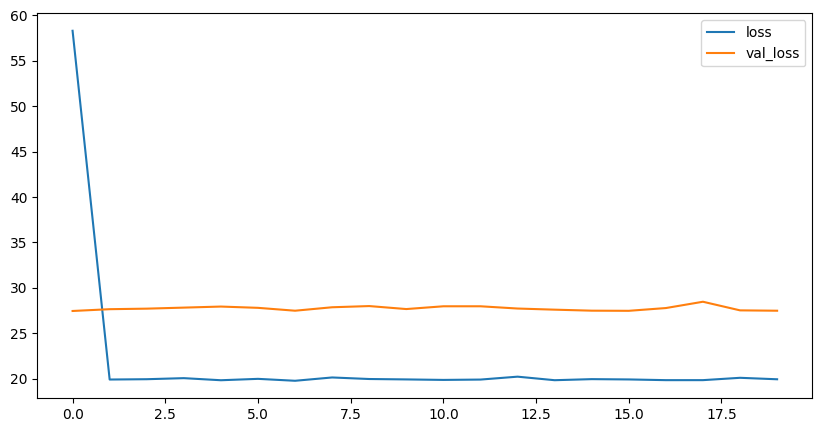

In [ ]:
# 1. 데이터 새로 정의
X_check = data[['studytime', 'traveltime', 'studytime', 'health']]
y_check = data['G3']

print(X_check.columns.tolist())

# 2. 분할
from sklearn.model_selection import train_test_split
X_train_check, X_test_check, y_train_check, y_test_check = train_test_split(
    X_check, y_check,
    test_size=0.25,
    random_state=2026
)

print(X_train_check.shape, y_train_check.shape)

# 3. 모델 새로 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense

model_check = Sequential()
model_check.add(InputLayer(shape=(4, )))
model_check.add(Dense(64, activation='sigmoid'))
model_check.add(Dense(32, activation='sigmoid'))
model_check.add(Dense(1))

model_check.summary()

# 4. 컴파일
model_check.compile(
    loss='mean_squared_error',
    optimizer='SGD',
    metrics=['mse']
)

# 5. 학습
h_check = model_check.fit(
    X_train_check, y_train_check,
    validation_split=0.2,
    epochs=20
)

# 6. history 직접 확인
print(h_check.history['loss'][:5])
print(h_check.history['val_loss'][:5])

# 7. 그래프
plt.figure(figsize=(10,5))
plt.plot(h_check.history['loss'], label='loss')
plt.plot(h_check.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 41.0934 - mse: 41.0934 - val_loss: 26.4580 - val_mse: 26.4580
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 18.6704 - mse: 18.6704 - val_loss: 25.2861 - val_mse: 25.2861
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 17.8604 - mse: 17.8604 - val_loss: 24.8691 - val_mse: 24.8691
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 17.8045 - mse: 17.8045 - val_loss: 24.5630 - val_mse: 24.5630
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 17.5935 - mse: 17.5935 - val_loss: 24.1351 - val_mse: 24.1351
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 17.2710 - mse: 17.2710 - val_loss: 23.4480 - val_mse: 23.4480
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 16.6165 - mse: 16.6165 - val_loss: 23.3566 - val_mse: 23.3566
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 16.2096 - mse: 16.2096 - val_loss: 22.9810 - val_mse: 22.9810
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

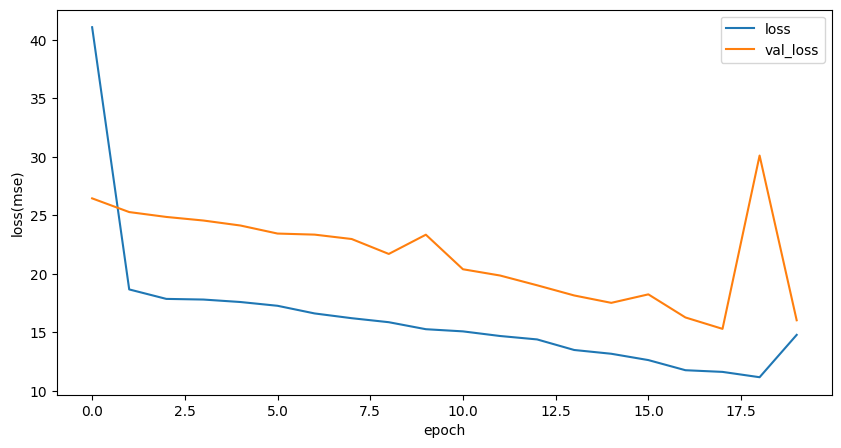

In [ ]:
# 1. 4개 컬럼 골라서  문제 데이터 다시 정의
X = data[["G1", "absences", "G2", "failures"]]
X.shape

# 2. train, test 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.25,
    random_state = 2026
)

# 3. 신경망 구조 설계 → model3
# 1) 뼈대 설계
model3 = Sequential()
# 2) 입력층 추가
# 주의 : 문제 데이터 형태 고려해서 shape 입력
model3.add(InputLayer(shape = (4, )))
# 3) 중간층 추가 → 첫번째 모델과 동일한 형태
model3.add(Dense(64, activation="sigmoid"))
model3.add(Dense(32, activation="sigmoid"))
# 4) 출력층 추가
model3.add(Dense(1))

# 4. 학습 방법  → 첫번째 모델과 동일한 형태
model3.compile(
    loss="mean_squared_error",
    optimizer = "SGD",
    metrics = ["mse"]
)

# 5. 학습 → 첫번째 모델과 동일한 형태
h2 = model3.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20
)

# 6. 학습 결과 시각화
# 학습 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(h2.history["loss"], label="loss")
plt.plot(h2.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss(mse)")
plt.legend()

plt.show()
# 그래프 캡쳐해서 단톡방에 올리기!

In [ ]:
# 특성들 모두 사용해서 (+ object도 인코딩해서)
# 딥러닝에 학습시켜보자~

# X 데이터 정의
# train, test 분리
# 딥러닝 모델 설계
# 컴파일(학습 방법 및 평가 방법)
# 학습 -> 현황 저장
# 그래프로 아까 특성 4개 선택했을 때보다 개선되는지 확인

In [ ]:
X = data.drop("G3", axis=1)
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.25,
    random_state = 2026
)

In [ ]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

In [ ]:
model4 = Sequential()

model4.add(InputLayer(shape=(X.shape[1],)))

model4.add(Dense(32, activation="relu"))
model4.add(Dense(64, activation="relu"))
model4.add(Dense(128, activation="relu"))
model4.add(Dense(64, activation="relu"))
model4.add(Dense(32, activation="relu"))

model4.add(Dense(1))

In [ ]:
model4.compile(
    loss="mean_squared_error",
    optimizer = "Adam",
    metrics = ["mse"]
)

In [ ]:
h4 = model4.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 100
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 71.0123 - mse: 71.0123 - val_loss: 26.1018 - val_mse: 26.1018
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 17.9037 - mse: 17.9037 - val_loss: 28.8712 - val_mse: 28.8712
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.8969 - mse: 11.8969 - val_loss: 16.5054 - val_mse: 16.5054
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4135 - mse: 9.4135 - val_loss: 15.0385 - val_mse: 15.0385
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.8777 - mse: 6.8777 - val_loss: 8.6254 - val_mse: 8.6254
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0632 - mse: 5.0632 - val_loss: 7.1552 - val_mse: 7.1552
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.7698 - mse: 4.7698 - val_loss: 6.8721 - val_mse: 6.8721
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0700 - mse: 4.0700 - val_loss: 5.8174 - val_mse: 5.8174
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 

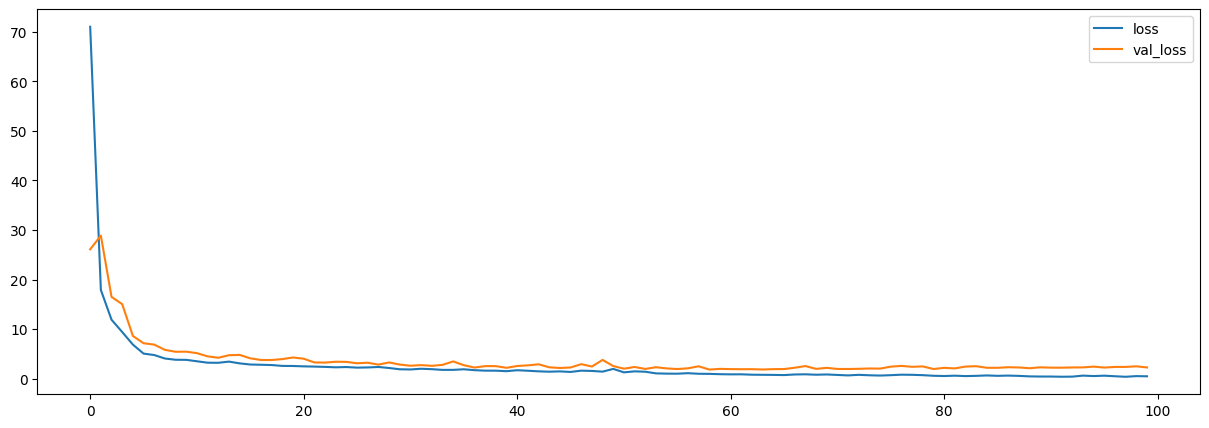

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(h4.history["loss"], label="loss")
plt.plot(h4.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

In [ ]:
X = data.drop(columns="G3")
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
cols = X.select_dtypes(include=["object"]).columns
X_label = X.copy()
for c in cols :
  X_label[c] = encoder.fit_transform(X[c])
X_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    int64
 1   sex         395 non-null    int64
 2   age         395 non-null    int64
 3   address     395 non-null    int64
 4   famsize     395 non-null    int64
 5   Pstatus     395 non-null    int64
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    int64
 9   Fjob        395 non-null    int64
 10  reason      395 non-null    int64
 11  guardian    395 non-null    int64
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    int64
 16  famsup      395 non-null    int64
 17  paid        395 non-null    int64
 18  activities  395 non-null    int64
 19  nursery     395 non-null    int64
 20  higher      395 non-null    int6

In [ ]:
X_onehot = pd.get_dummies(X)
X_onehot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 58 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                395 non-null    int64
 1   Medu               395 non-null    int64
 2   Fedu               395 non-null    int64
 3   traveltime         395 non-null    int64
 4   studytime          395 non-null    int64
 5   failures           395 non-null    int64
 6   famrel             395 non-null    int64
 7   freetime           395 non-null    int64
 8   goout              395 non-null    int64
 9   Dalc               395 non-null    int64
 10  Walc               395 non-null    int64
 11  health             395 non-null    int64
 12  absences           395 non-null    int64
 13  G1                 395 non-null    int64
 14  G2                 395 non-null    int64
 15  school_GP          395 non-null    bool 
 16  school_MS          395 non-null    bool 
 17  sex_F           

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_label, y,
    test_size=0.3,
    random_state = 10
)

In [ ]:
model4 = Sequential()

model4.add(InputLayer(shape=X_train.iloc[0].shape))

model4.add(Dense(16, activation="relu"))
model4.add(Dense(32, activation="relu"))
model4.add(Dense(64, activation="relu"))
model4.add(Dense(32, activation="relu"))
model4.add(Dense(16, activation="relu"))

model4.add(Dense(1))

In [ ]:
model4.compile(
    loss="mean_squared_error",
    optimizer = "Adam",
    metrics = ["mse"]
)

In [ ]:
h4 = model4.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 20
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 108.7458 - mse: 108.7458 - val_loss: 102.1019 - val_mse: 102.1019
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 80.3334 - mse: 80.3334 - val_loss: 68.8138 - val_mse: 68.8138
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 49.9627 - mse: 49.9627 - val_loss: 32.5117 - val_mse: 32.5117
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20.0178 - mse: 20.0178 - val_loss: 10.2148 - val_mse: 10.2148
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.9682 - mse: 9.9682 - val_loss: 15.6778 - val_mse: 15.6778
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 11.9684 - mse: 11.9684 - val_loss: 10.2393 - val_mse: 10.2393
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.1391 - mse: 8.1391 - val_loss: 8.0975 - val_mse: 8.0975
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7.3991 - mse: 7.3991 - val_loss: 6.9110 - val_mse: 6.9110
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - los

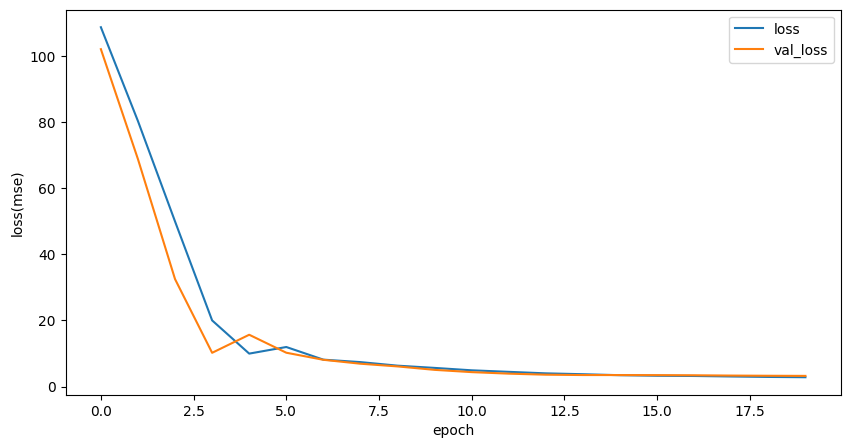

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(h4.history["loss"], label="loss")
plt.plot(h4.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss(mse)")
plt.legend()

plt.show()